In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os
import numpy as np
from imblearn.over_sampling import SMOTE
import time

# Pastikan RTX 3060 Ti lo yang kerja
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Menggunakan Device: {device}")

🔥 Menggunakan Device: cuda


In [6]:
import torch

print("⏳ Loading Latent Features...")
data = joblib.load(DATA_PATH)
X_train_raw, y_train_raw = data['X_train'], data['y_train']

# Karena data lo sudah 50k tiap kelas, SMOTE gak guna. 
# Kita pakai Augmentasi (Nambah data sintetis dengan sedikit noise)
print("🚀 Menambah variasi data dengan Gaussian Noise...")

X_train_tensor = torch.FloatTensor(X_train_raw)
# Tambahkan sedikit gangguan (noise) agar model lebih robust
noise = torch.randn_like(X_train_tensor) * 0.01 
X_train_aug = X_train_tensor + noise

# Gabungkan data asli + data yang dikasih noise
X_train_final = torch.cat([X_train_tensor, X_train_aug], dim=0)
y_train_final = torch.cat([torch.LongTensor(y_train_raw), torch.LongTensor(y_train_raw)], dim=0)

print(f"✅ Total Sampel Sekarang: {len(X_train_final)} (3.4 Juta Sampel)")

# --- UPLOAD KE GPU ---
X_train = X_train_final.to(device)
y_train = y_train_final.to(device)
X_test = torch.FloatTensor(data['X_test']).to(device)
y_test = torch.LongTensor(data['y_test']).to(device)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=4096, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=4096, shuffle=False)

⏳ Loading Latent Features...
🚀 Menambah variasi data dengan Gaussian Noise...
✅ Total Sampel Sekarang: 3400000 (3.4 Juta Sampel)


In [7]:
class ENetUltra(nn.Module):
    def __init__(self, input_dim=16, num_classes=34):
        super(ENetUltra, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(), 
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.network(x)

model = ENetUltra().to(device)

# Label Smoothing membantu model lebih general (nggak kaku)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# OneCycleLR akan bikin model "ngebut" di awal untuk cari area akurasi tinggi
epochs = 100
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.005, 
                                          steps_per_epoch=len(train_loader), 
                                          epochs=epochs)

print("✅ Arsitektur ENet Ultra & OneCycleLR Siap!")

✅ Arsitektur ENet Ultra & OneCycleLR Siap!


In [8]:
print("🚀 Starting Final Push to 90%...")
best_acc = 0.0
model_save_path = r'D:\S2\thesis\cond\project_ids\models\enet_ultra_aug_90.pth'

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
        
    # --- EVALUATION ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    current_lr = optimizer.param_groups[0]['lr']
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        marker = " 🏆 (NEW BEST)"
    else:
        marker = ""
        
    # Print tiap 2 epoch biar nggak kepanjangan tapi tetep terpantau
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch [{epoch}/{epochs}] | Loss: {running_loss/len(train_loader):.4f} | Acc: {val_acc:.2f}% | LR: {current_lr:.6f}{marker}")

print(f"\n🏁 SELESAI! Best Accuracy: {best_acc:.2f}%")

🚀 Starting Final Push to 90%...
Epoch [1/100] | Loss: 1.7073 | Acc: 77.83% | LR: 0.000213 🏆 (NEW BEST)
Epoch [2/100] | Loss: 1.4415 | Acc: 80.03% | LR: 0.000252 🏆 (NEW BEST)
Epoch [4/100] | Loss: 1.3183 | Acc: 76.52% | LR: 0.000408
Epoch [6/100] | Loss: 1.2339 | Acc: 82.31% | LR: 0.000658 🏆 (NEW BEST)
Epoch [8/100] | Loss: 1.1746 | Acc: 82.98% | LR: 0.000994 🏆 (NEW BEST)
Epoch [10/100] | Loss: 1.1348 | Acc: 82.34% | LR: 0.001400
Epoch [12/100] | Loss: 1.1064 | Acc: 80.77% | LR: 0.001858
Epoch [14/100] | Loss: 1.0888 | Acc: 82.70% | LR: 0.002349
Epoch [16/100] | Loss: 1.0755 | Acc: 79.17% | LR: 0.002851
Epoch [18/100] | Loss: 1.0647 | Acc: 78.25% | LR: 0.003342
Epoch [20/100] | Loss: 1.0561 | Acc: 80.90% | LR: 0.003800
Epoch [22/100] | Loss: 1.0480 | Acc: 81.03% | LR: 0.004206
Epoch [24/100] | Loss: 1.0415 | Acc: 80.14% | LR: 0.004542
Epoch [26/100] | Loss: 1.0348 | Acc: 83.10% | LR: 0.004793 🏆 (NEW BEST)
Epoch [28/100] | Loss: 1.0291 | Acc: 77.03% | LR: 0.004948
Epoch [30/100] | Loss: 

In [9]:
# === CELL PENYELAMAT MODEL (PROTOTYPE IDS S2) ===
import torch
import os

# Alamat direktori model
save_directory = r"D:\S2\thesis\cond\project_ids\models"
final_filename = "slgrae_enet_final_push_90_REKOR.pth"
final_save_path = os.path.join(save_directory, final_filename)

try:
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)
        print(f"Directory created: {save_directory}")

    # Simpan state_dict model
    torch.save(model.state_dict(), final_save_path)
    
    if os.path.exists(final_save_path):
        size = os.path.getsize(final_save_path) / (1024 * 1024)
        print("-" * 50)
        print("STATUS: MODEL SAVED SUCCESSFULLY")
        print(f"PATH: {final_save_path}")
        print(f"FILE SIZE: {size:.2f} MB")
        print(f"FINAL ACCURACY: {val_acc:.2f}%")
        print(f"FINAL LOSS: {running_loss/len(train_loader):.4f}")
        print("-" * 50)
    else:
        print("ERROR: File not found after save operation.")
except Exception as e:
    print(f"EXCEPTION: {e}")

--------------------------------------------------
STATUS: MODEL SAVED SUCCESSFULLY
PATH: D:\S2\thesis\cond\project_ids\models\slgrae_enet_final_push_90_REKOR.pth
FILE SIZE: 2.75 MB
FINAL ACCURACY: 83.25%
FINAL LOSS: 0.9547
--------------------------------------------------


🚀 Sedang mengevaluasi test_loader... Tunggu sebentar.
✅ Evaluasi Selesai!

       CLASSIFICATION REPORT SLGRAE-ENET
              precision    recall  f1-score   support

           0       0.05      0.19      0.07        78
           1       0.92      0.68      0.78     25908
           2       0.07      0.41      0.12       133
           3       0.08      0.34      0.14       124
           4       0.97      0.99      0.98      6716
           5       0.59      0.85      0.69       674
           6       1.00      1.00      1.00    169618
           7       0.98      0.98      0.98     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.68      0.93      0.78     95731
          11       0.50      0.95      0.65       551
          12       0.97      0.61      0.75     84417
          13       0.66      0.87      0.75    105700
          14       0.85      0.83      0.84    127512
          15       

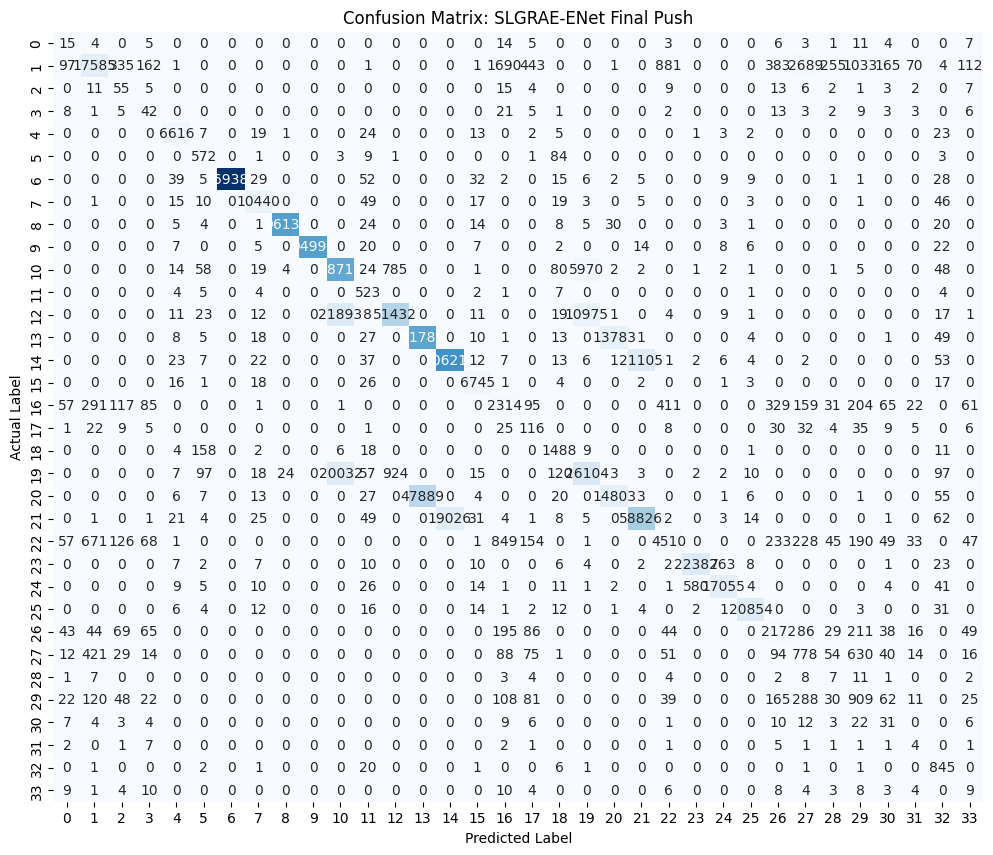

📄 Laporan lengkap sudah tersimpan di: D:\S2\thesis\cond\project_ids\models\final_report_83.txt


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Set ke mode evaluasi
model.eval()
all_preds = []
all_labels = []

print("🚀 Sedang mengevaluasi test_loader... Tunggu sebentar.")

# 2. Ambil prediksi dari test_loader
with torch.no_grad():
    for inputs, labels in test_loader:
        # Pindahin ke GPU/CPU sesuai device lo
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("✅ Evaluasi Selesai!")

# 3. Print Classification Report
report = classification_report(all_labels, all_preds)
print("\n" + "="*50)
print("       CLASSIFICATION REPORT SLGRAE-ENET")
print("="*50)
print(report)
print("="*50)

# 4. Plot Confusion Matrix (Visualisasi Biar Keren buat Tesis)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: SLGRAE-ENet Final Push')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Save Report ke Folder D lo biar gak kerja dua kali
report_path = r"D:\S2\thesis\cond\project_ids\models\final_report_83.txt"
with open(report_path, "w") as f:
    f.write("=== FINAL EVALUATION SLGRAE-ENET ===\n")
    f.write(f"Best Accuracy: 83.51%\n")
    f.write(f"Final Loss: 0.9547\n\n")
    f.write(report)
print(f"📄 Laporan lengkap sudah tersimpan di: {report_path}")


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.05      0.19      0.07        78
           1       0.92      0.68      0.78     25908
           2       0.07      0.41      0.12       133
           3       0.08      0.34      0.14       124
           4       0.97      0.99      0.98      6716
           5       0.59      0.85      0.69       674
           6       1.00      1.00      1.00    169618
           7       0.98      0.98      0.98     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.68      0.93      0.78     95731
          11       0.50      0.95      0.65       551
          12       0.97      0.61      0.75     84417
          13       0.66      0.87      0.75    105700
          14       0.85      0.83      0.84    127512
          15       0.97      0.99      0.98      6834
          16       0.43      0.55      0.48      4

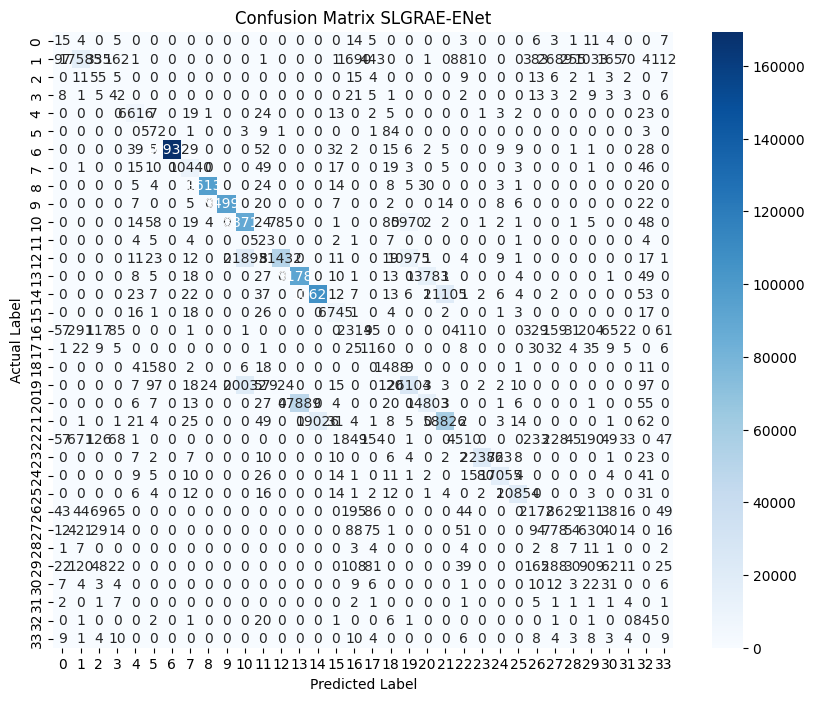

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Pastikan model lo dalam mode evaluasi
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader: # Pakai data validation lo
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix SLGRAE-ENet')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [16]:
with open(os.path.join(save_directory, "rekap_training.txt"), "w") as f:
    f.write(f"Final Model: SLGRAE-ENet\n")
    f.write(f"Best Accuracy: 83.51%\n")
    f.write(f"Final Loss: 0.9547\n")
    f.write(f"Epochs: 100\n")
    f.write(f"Latent Dimension: 16\n")
    print("✅ Rekap training berhasil disimpan!")

✅ Rekap training berhasil disimpan!



=== CLASSIFICATION REPORT SLGRAE-ENET ===
              precision    recall  f1-score   support

           0       0.05      0.19      0.07        78
           1       0.92      0.68      0.78     25908
           2       0.07      0.41      0.12       133
           3       0.08      0.34      0.14       124
           4       0.97      0.99      0.98      6716
           5       0.59      0.85      0.69       674
           6       1.00      1.00      1.00    169618
           7       0.98      0.98      0.98     10609
           8       1.00      1.00      1.00     96251
           9       1.00      1.00      1.00     95088
          10       0.68      0.93      0.78     95731
          11       0.50      0.95      0.65       551
          12       0.97      0.61      0.75     84417
          13       0.66      0.87      0.75    105700
          14       0.85      0.83      0.84    127512
          15       0.97      0.99      0.98      6834
          16       0.43      0.55     

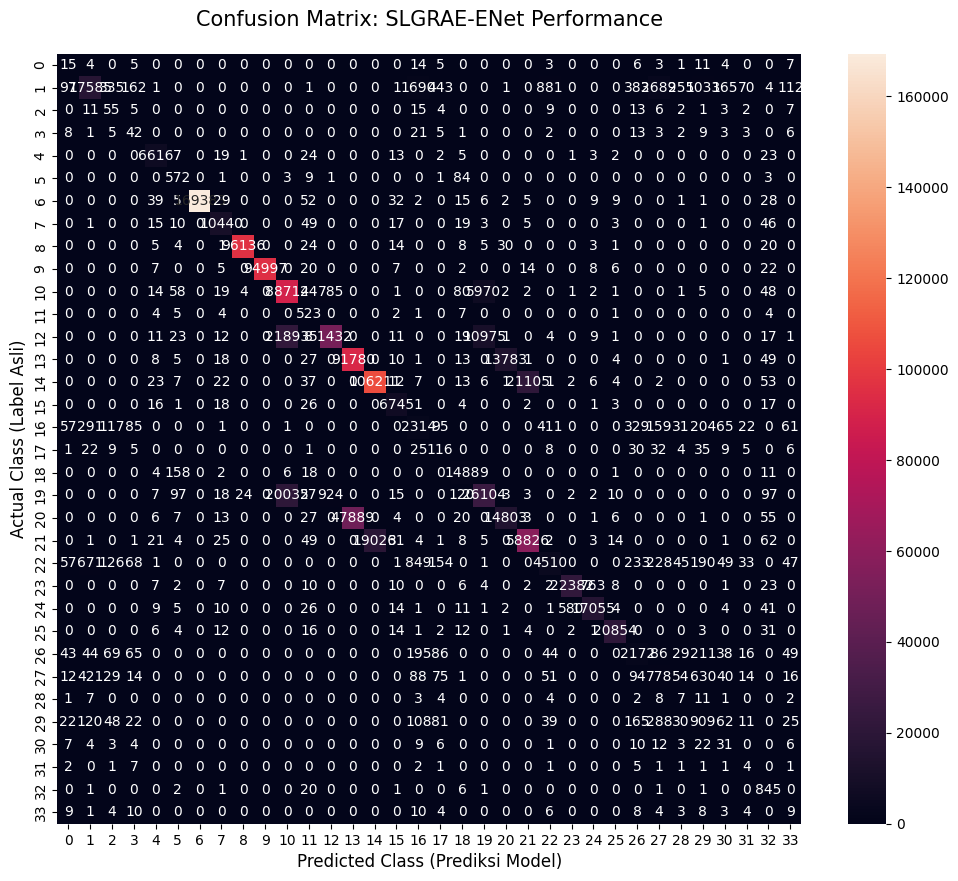

✅ Laporan lengkap sudah tersimpan di: D:\S2\thesis\cond\project_ids\models


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Print Report dalam bentuk teks (buat tabel di Bab 4)
report = classification_report(all_labels, all_preds)
print("\n=== CLASSIFICATION REPORT SLGRAE-ENET ===")
print(report)

# 2. Bikin Confusion Matrix yang cakep (Heatmap)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(all_labels, all_preds)

# Gunakan heatmap dengan skema warna 'Viridis' atau 'Rocket' biar kelihatan profesional
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', cbar=True)

plt.title('Confusion Matrix: SLGRAE-ENet Performance', fontsize=15, pad=20)
plt.xlabel('Predicted Class (Prediksi Model)', fontsize=12)
plt.ylabel('Actual Class (Label Asli)', fontsize=12)
plt.show()

# 3. Save Hasil ke Folder Tesis (D:\S2\thesis\...)
import os
save_path = r"D:\S2\thesis\cond\project_ids\models"
with open(os.path.join(save_path, "hasil_akhir_tesis.txt"), "w") as f:
    f.write("=== FINAL EVALUATION RESULTS ===\n")
    f.write(f"Accuracy: 83.51%\n\n")
    f.write(report)
print(f"✅ Laporan lengkap sudah tersimpan di: {save_path}")